In [ ]:
import numpy as np
import mcstasscript as ms


def add_multi_gap_chopper(
    name,
    instrument,
    ref,
    gaps,
    positions,
    phase_variable,
    other_parameters_dict,
    add_enable_par=False,
    add_jitter_par=False,
    above=False,
    multi=False,
):

    if multi:
        return add_multi_gap_chopper_multi(
            name,
            instrument,
            ref,
            gaps,
            positions,
            phase_variable,
            other_parameters_dict,
            add_enable_par=add_enable_par,
            add_jitter_par=add_jitter_par,
            above=above,
        )
    else:
        return add_multi_gap_chopper_group(
            name,
            instrument,
            ref,
            gaps,
            positions,
            phase_variable,
            other_parameters_dict,
            add_enable_par=add_enable_par,
            add_jitter_par=add_jitter_par,
            above=above,
        )


def add_multi_gap_chopper_group(
    name,
    instrument,
    ref,
    gaps,
    positions,
    phase_variable,
    other_parameters_dict,
    add_enable_par=False,
    add_jitter_par=False,
    above=False,
):
    """

    :param name: name of chopper
    :param instrument: mcstasscript instrument object
    :param ref: component name where this chopper will be placed
    :param gaps: list of gap sizes in [deg]
    :param positions: list of slit positions on disk, center of gaps, given in [deg]
    :param phase_variable: string with variable of phase for the chopper, given for first gap in list
    :param other_parameters_dict: dictionary with other parameters
    :param add_jitter_par: If True, the function adds a jitter parameter for the chopper
    :param above: If True, the chopper is placed above the beam instead of the default below
    :return:
    """

    alphabet = ["a", "b", "c", "d", "e", "f", "g", "h"]
    alphabet_index = 0

    if add_enable_par:
        enable_par_name = f"enable_{name}"
        instrument.add_parameter(
            "int",
            enable_par_name,
            value=1,
            comment=f"Set to 1 to enable {name} chopper.",
        )
        WHEN = f"{enable_par_name} == 1"

    if add_jitter_par:
        jitter_par = instrument.add_parameter(
            f"jitter_{name}", value=0, comment=f"Jitter of {name} chopper."
        )

    after = ref
    for gap, position in zip(gaps, positions):
        # grab next letter in alphabet
        letter = alphabet[alphabet_index]
        alphabet_index = alphabet_index + 1

        # Insert chopper in instrument after designated "after" component
        chopper = instrument.add_component(name + letter, "DiskChopper", after=after)
        chopper.theta_0 = gap
        chopper.phase = phase_variable + " + " + str(position)
        chopper.nslit = 1

        if add_jitter_par:
            chopper.jitter = jitter_par

        chopper.set_parameters(other_parameters_dict)

        # Keep these choppers in a group
        chopper.set_GROUP(name)
        # Could add false frame metadata

        # Place chopper relative to ref
        chopper.set_RELATIVE(ref)

        if above:
            chopper.set_ROTATED([0, 0, 180], RELATIVE=ref)

        # Update after to this chopper so next chopper is placed after this one
        after = chopper


def add_multi_gap_chopper_multi(
    name,
    instrument,
    ref,
    gaps,
    positions,
    phase_variable,
    other_parameters_dict,
    add_enable_par=False,
    add_jitter_par=False,
    above=False,
):
    """

    :param name: name of chopper
    :param instrument: mcstasscript instrument object
    :param ref: component name where this chopper will be placed
    :param gaps: list of gap sizes in [deg]
    :param positions: list of slit positions on disk, center of gaps, given in [deg]
    :param phase_variable: string with variable of phase for the chopper, given for first gap in list
    :param other_parameters_dict: dictionary with other parameters
    :param add_jitter_par: If True, the function adds a jitter parameter for the chopper
    :param above: If True, the chopper is placed above the beam instead of the default below
    :return:
    """

    if add_enable_par:
        enable_par_name = f"enable_{name}"
        instrument.add_parameter(
            "int",
            enable_par_name,
            value=1,
            comment=f"Set to 1 to enable {name} chopper.",
        )
        WHEN = f"{enable_par_name} == 1"

    if add_jitter_par:
        jitter_par = instrument.add_parameter(
            f"jitter_{name}", value=0, comment=f"Jitter of {name} chopper."
        )

    after = ref
    slit_width_string = ";".join(str(n) for n in gaps)
    slit_center_string = ";".join(str(-n) for n in positions)
    assert len(gaps) == len(positions)

    chopper = instrument.add_component(name, "MultiDiskChopper", after=after)
    chopper.set_parameters(
        slit_width='"' + slit_width_string + '"',
        slit_center='"' + slit_center_string + '"',
        phase=phase_variable,
        nslits=len(gaps),
    )

    if add_jitter_par:
        chopper.jitter = jitter_par

    if "yheight" in other_parameters_dict:
        other_parameters_dict["delta_y"] = (
            other_parameters_dict["yheight"] / 2 - other_parameters_dict["radius"]
        )
        # other_parameters_dict["delta_y"] = - other_parameters_dict["yheight"]/2 + other_parameters_dict["radius"]
        # other_parameters_dict["delta_y"] = -0.01 #other_parameters_dict["radius"]
        del other_parameters_dict["yheight"]

    if "nu" in other_parameters_dict:
        other_parameters_dict["nu"] = other_parameters_dict["nu"]

    chopper.set_parameters(other_parameters_dict)

    if add_enable_par:
        chopper.set_WHEN(WHEN)

    # Place chopper relative to ref
    chopper.set_RELATIVE(ref)

    if above:
        chopper.set_ROTATED([0, 0, 180], RELATIVE=ref)

In [ ]:
instr = ms.McStas_instr("test", input_path="clean_input_path", output_path="data/data")
instr.settings(suppress_output=True)

source = instr.add_component("Source", "Source_div")
source.set_parameters(
    xwidth=2.0, yheight=2.0, focus_ah=0.001, focus_aw=0.001, E0=5, dE=0.1
)

chopper_arm = instr.add_component("ref", "Arm", RELATIVE=source, AT=[0, 0.0, 1])

phase = instr.add_parameter("double", "phase_var", value=0)

add_multi_gap_chopper(
    "chopper",
    instrument=instr,
    ref=chopper_arm,
    # gaps=[20, 20, 35, 35],positions=[0, 180, 55, 235],
    gaps=[35, 20, 55, 35],
    positions=[0, 180, 55, 235],
    phase_variable=phase.name,
    other_parameters_dict=dict(radius=0.4, yheight=0.02, nu=0.0001),
    add_enable_par=False,
    add_jitter_par=False,
    above=False,
    multi=False,
)

PSD = instr.add_component("PSD", "PSD_monitor", AT=2, RELATIVE=source)
PSD.set_parameters(xwidth=source.xwidth, yheight=source.yheight, nx=300, ny=300)

COMPONENT choppera = DiskChopper(
  theta_0 = 35, // [deg]
  radius = 0.4, // [m]
  yheight = 0.02, // [m]
  nu = 0.0001, // [Hz]
  nslit = 1, // [1]
  phase = phase_var + 0 // [deg]
)
AT (0, 0, 0) RELATIVE ref
GROUP chopper
COMPONENT chopperc = DiskChopper(
  theta_0 = 55, // [deg]
  radius = 0.4, // [m]
  yheight = 0.02, // [m]
  nu = 0.0001, // [Hz]
  nslit = 1, // [1]
  phase = phase_var + 55 // [deg]
)
AT (0, 0, 0) RELATIVE ref
GROUP chopper
double phase_var  = 0  // 


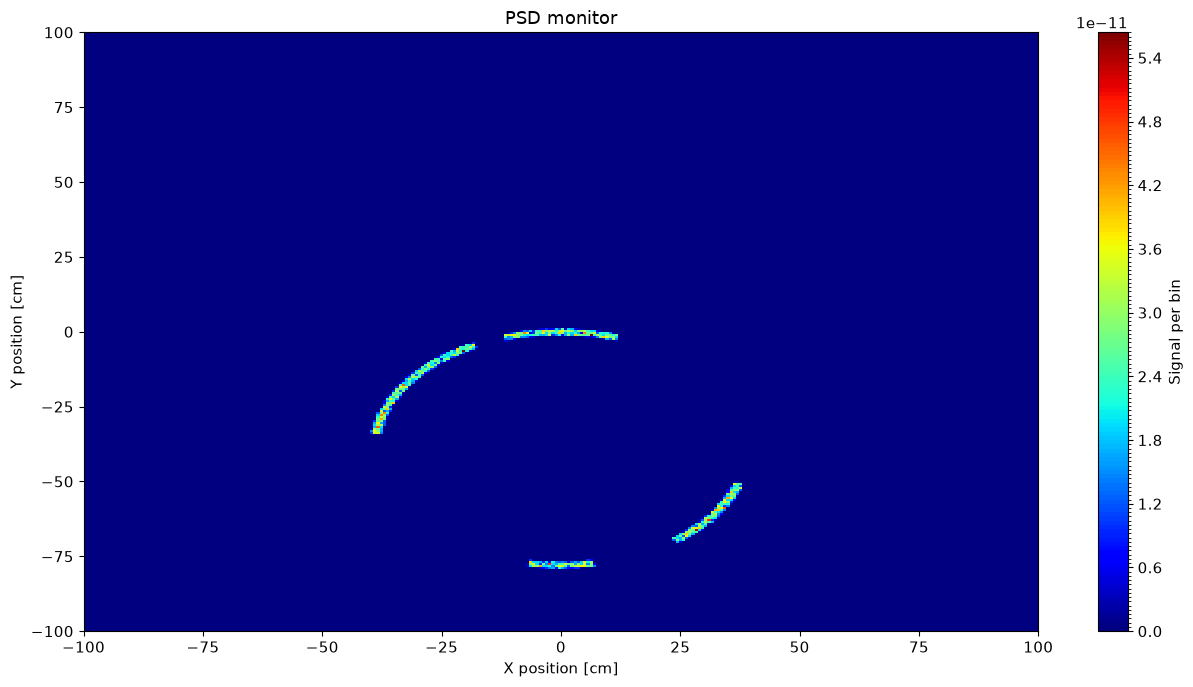

In [3]:
chopper = instr.get_component("choppera")
print(chopper)
print(instr.get_component("chopperc"))
instr.show_parameters()
data = instr.backengine()
ms.make_plot(data)

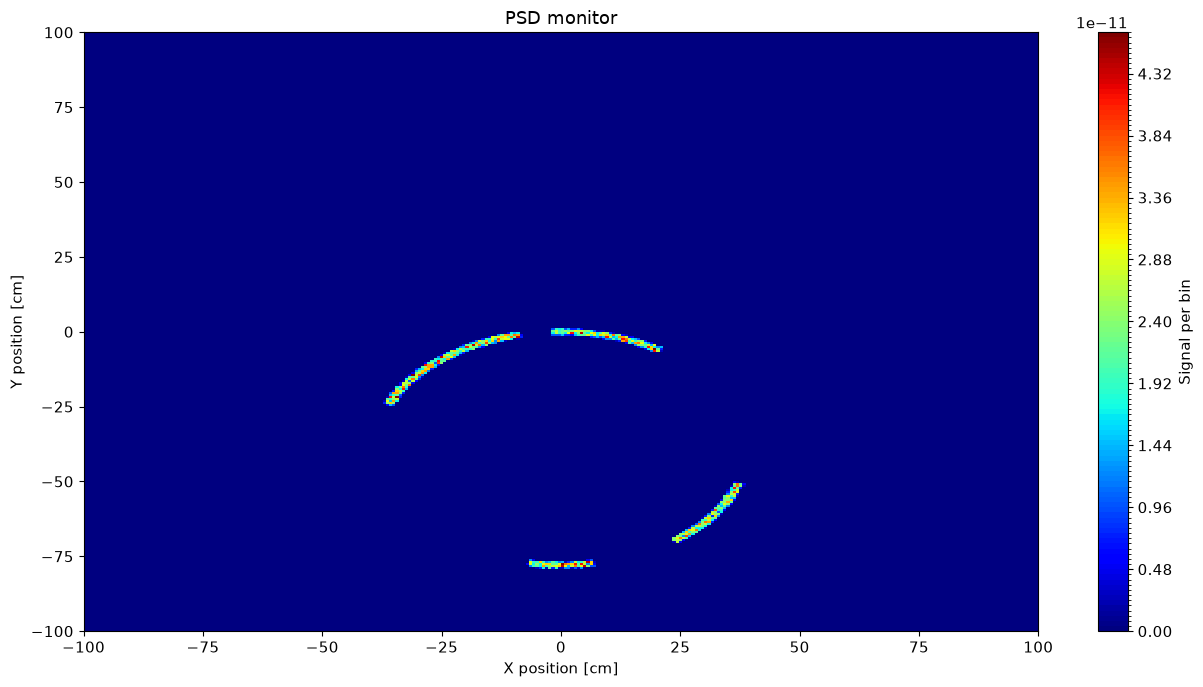

In [ ]:
chopper.nu = 40
instr.get_component("chopperc").nu = 40
data = instr.backengine()
ms.make_plot(data)

In [5]:
instr.show_instrument()

In [ ]:
instr = ms.McStas_instr("test", input_path="clean_input_path", output_path="data/data")
instr.settings(suppress_output=True)

source = instr.add_component("Source", "Source_div")
source.set_parameters(
    xwidth=2.0, yheight=2.0, focus_ah=0.001, focus_aw=0.001, E0=5, dE=2
)

chopper_arm = instr.add_component("ref", "Arm", RELATIVE=source, AT=[0, 0.0, 1])

phase = instr.add_parameter("double", "phase_var", value=0)

add_multi_gap_chopper(
    "chopper",
    instrument=instr,
    ref=chopper_arm,
    # gaps=[20, 20, 35, 35], positions=[0, 180, -55, -235],
    gaps=[35, 20, 55, 35],
    positions=[0, 180, 55, 235],
    phase_variable=phase.name,
    other_parameters_dict=dict(radius=0.4, yheight=0.02, nu=0.0001),
    add_enable_par=False,
    add_jitter_par=False,
    above=False,
    multi=True,
)

PSD = instr.add_component("PSD", "PSD_monitor", AT=2, RELATIVE=source)
PSD.set_parameters(xwidth=source.xwidth, yheight=source.yheight, nx=300, ny=300)

In [7]:
chopper = instr.get_component("chopper")
print(chopper)
data = instr.backengine()

COMPONENT chopper = MultiDiskChopper(
  slit_center = "0;-180;-55;-235", // [string]
  slit_width = "35;20;55;35", // [string]
  nslits = 4, // []
  delta_y = -0.39, // [m]
  nu = 0.0001, // [Hz]
  phase = phase_var, // [deg]
  radius = 0.4 // [m]
)
AT (0, 0, 0) RELATIVE ref


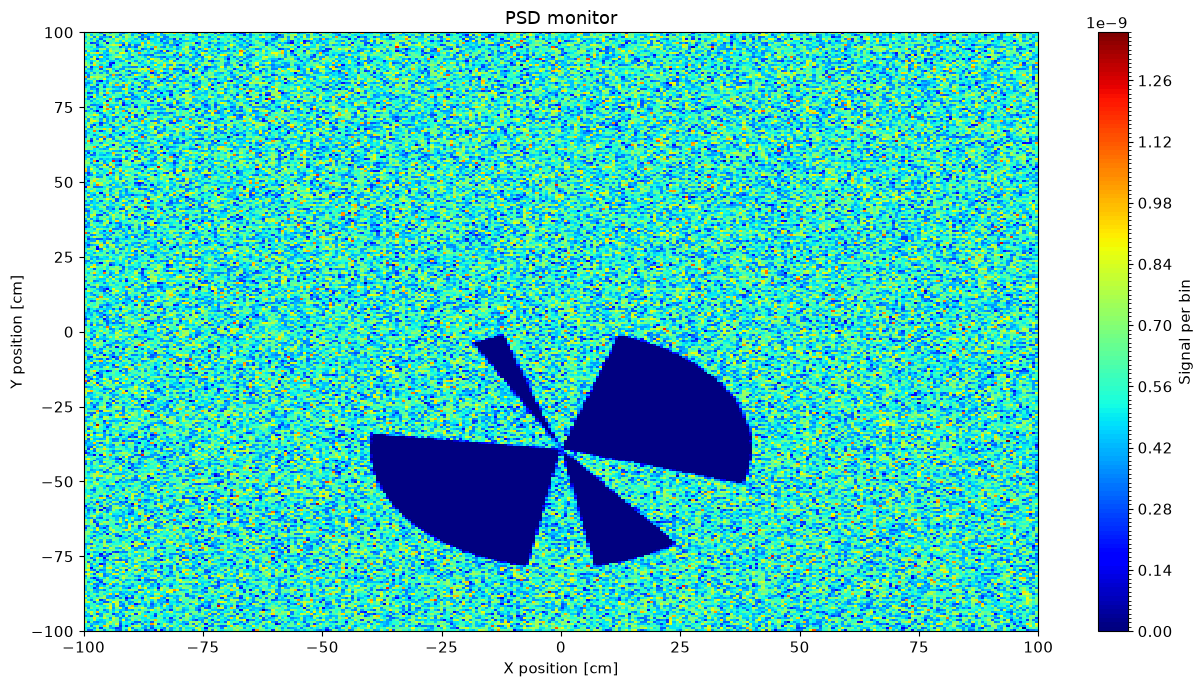

In [8]:
ms.make_plot(data)

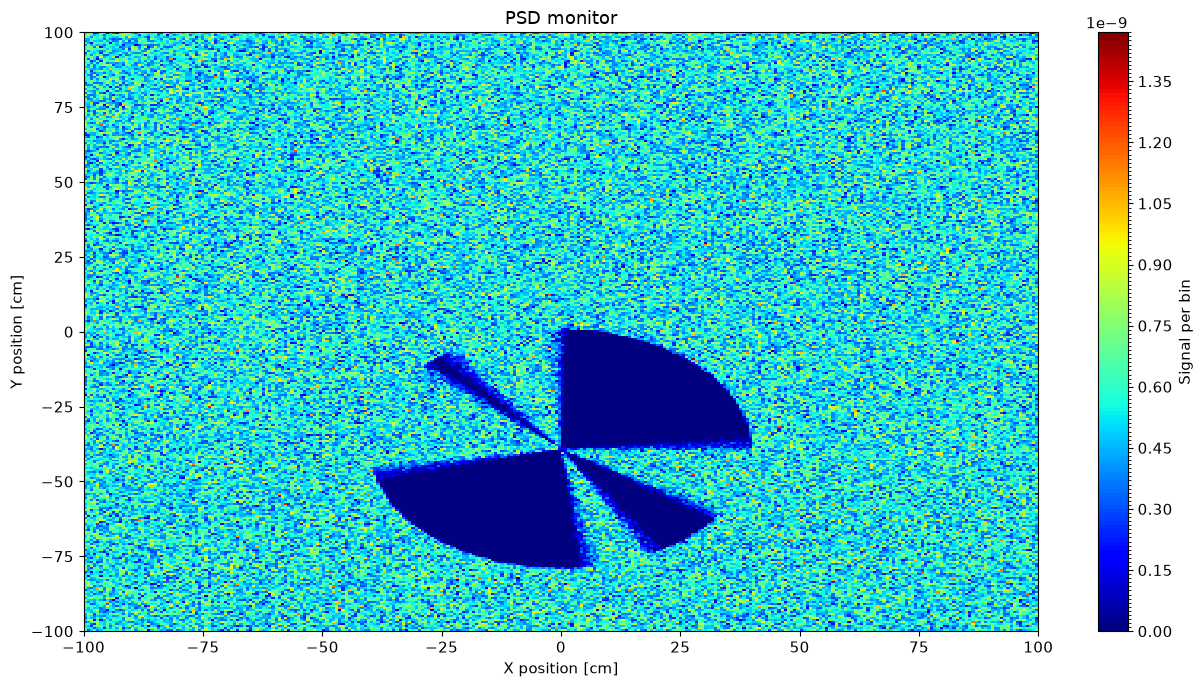

In [9]:
chopper.nu = 50
data = instr.backengine()
ms.make_plot(data)

In [10]:
instr.show_instrument()

In [11]:
chopper.delta_y = 0.3
instr.show_instrument()

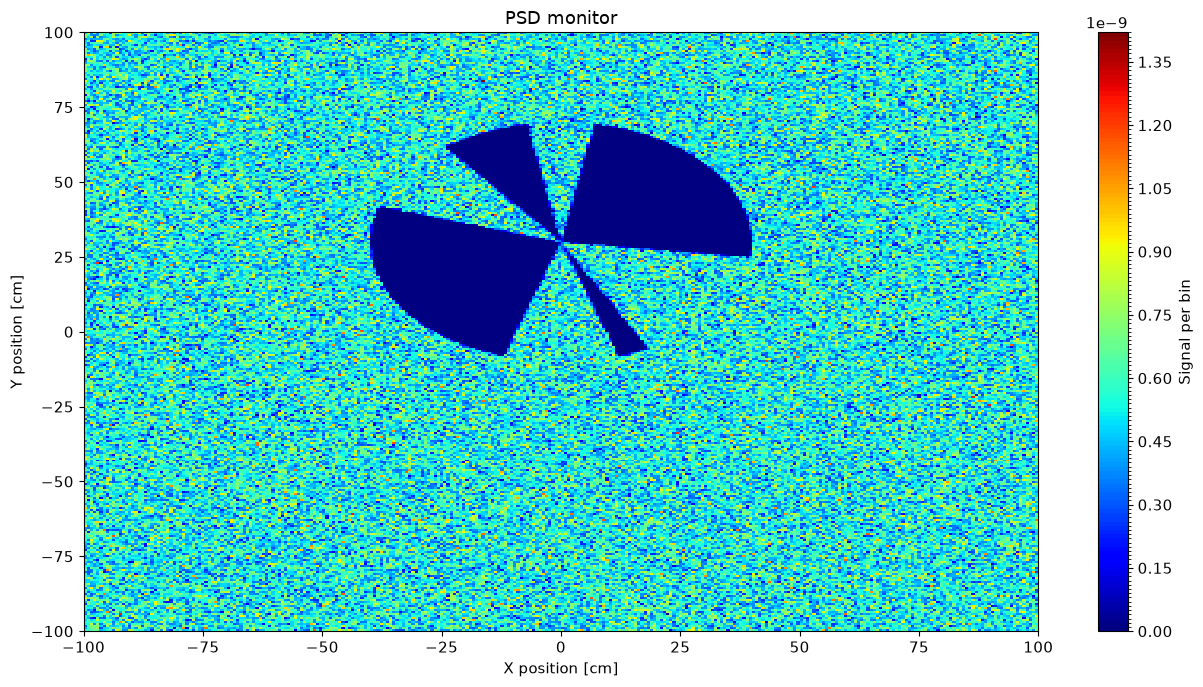

In [12]:
chopper.nu = 0.001
data = instr.backengine()
ms.make_plot(data)

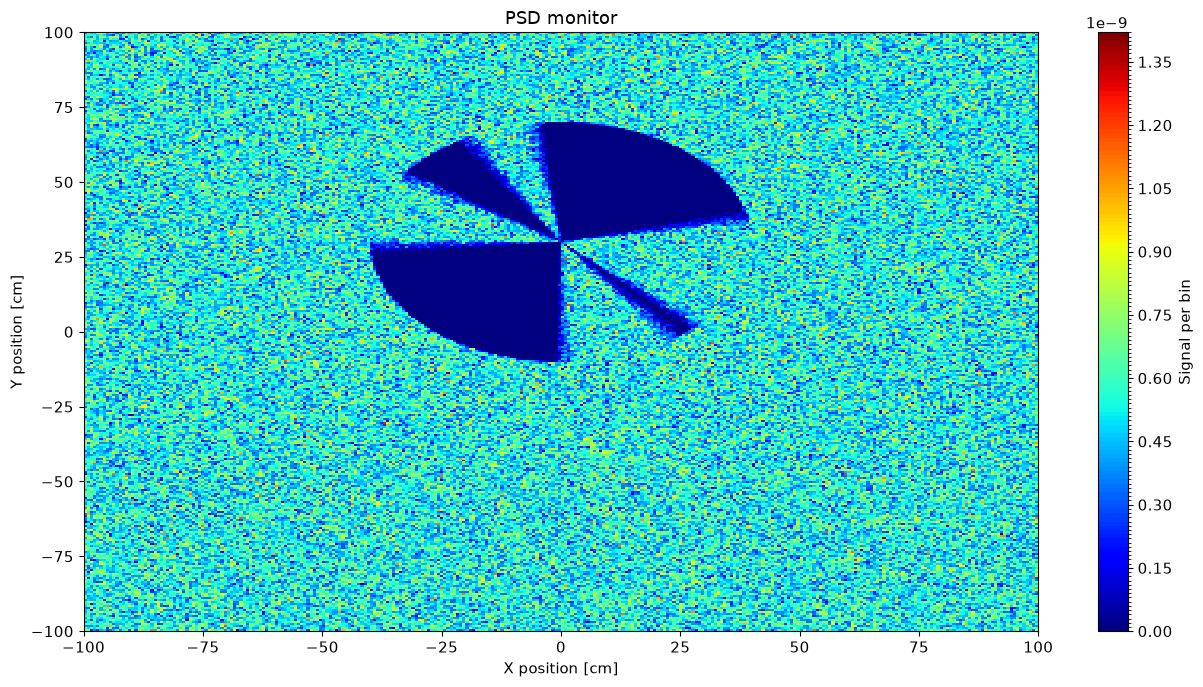

In [13]:
chopper.nu = 50
data = instr.backengine()
ms.make_plot(data)